# Análise de preços de imóveis com regressão linear
## House Sales in King County, USA

**Trabalho de análise de dados e modelagem estatística**

### 1. Introdução e objetivo
O preço de um imóvel pode estar relacionado à sua área, qualidade de construção, quantidade de banheiros, ano de construção e localização. Neste trabalho, vamos estudar essas relações utilizando uma base de vendas de imóveis de King County, nos Estados Unidos, referente a 2014 e 2015.

O objetivo é realizar uma **análise descritiva**, verificar a **qualidade dos dados** e ajustar dois modelos: o **Modelo de Regressão Linear Simples (MRLS)** e o **Modelo de Regressão Linear Múltipla (MRLM)**. Depois, vamos avaliar os resíduos, interpretar os coeficientes e comparar o desempenho dos modelos.

As decisões serão fundamentadas nas tabelas, gráficos e testes calculados neste notebook. O trabalho é exploratório: uma associação estatística não demonstra que uma característica cause uma mudança no preço.

**Fonte:** [House Sales in King County, USA — Kaggle](https://www.kaggle.com/datasets/harlfoxem/housesalesprediction), identificador `harlfoxem/housesalesprediction`.

**Execução:** abrir no Jupyter ou Google Colab e executar as células na ordem. O notebook já contém os resultados da execução. O CSV está na pasta `data` do pacote completo. Sem o CSV local, o código tenta baixá-lo da fonte. Para usar um arquivo enviado ao Colab, ajuste `CAMINHO` na célula de leitura.

### 2. Legenda das variáveis utilizadas nos modelos

| Símbolo | Nome na base | Descrição | Unidade ou escala | Papel |
|---|---|---|---|---|
| \(Y\) | `price` | Preço de venda do imóvel. | Dólares americanos (US$), valores de 2014–2015. | Variável resposta. |
| \(X_1\) | `sqft_living` | Área habitável construída do imóvel. Não é a área do terreno. | Pés quadrados (sqft); 1 sqft ≈ 0,0929 m². | Explicativa no MRLS e no MRLM. |
| \(X_2\) | `grade` | Nota de qualidade da construção e do projeto do imóvel. Não é a mesma variável que `condition`, que descreve conservação. | Escala ordinal de 1 a 13; notas maiores representam padrão construtivo maior. | Explicativa no MRLM. |
| \(X_3\) | `bathrooms` | Quantidade de banheiros registrada na base, incluindo contagens fracionárias de banheiros parciais. | Número de banheiros; pode assumir valores como 1,5 ou 2,25. | Explicativa no MRLM. |
| \(X_4\) | `yr_built` | Ano de construção do imóvel. Não representa diretamente sua idade. | Ano, por exemplo, 1980. | Explicativa no MRLM. |
| \(X_5\) | `lat` | Latitude da localização do imóvel. Valores maiores indicam posições mais ao norte. | Graus decimais. | Explicativa no MRLM. |
| \(\ln(Y)\) | `log_price` | Logaritmo natural do preço, criado durante a análise para testar uma escala menos assimétrica. | Escala logarítmica do preço registrado em US$. | Resposta dos modelos transformados. |

**Outras colunas utilizadas na análise:** `id` identifica o imóvel; `date` informa a data da venda; `zipcode` é o código postal; `bedrooms` é o número de quartos; `sqft_lot` é a área do terreno; `sqft_above` é a área construída acima do solo; `sqft_basement` é a área do porão; `sqft_living15` é uma medida de área habitável dos imóveis vizinhos. Essas colunas auxiliam a inspeção ou a discussão e não são acrescentadas aos modelos propostos.

**Notação:** \(\beta_0\) é o intercepto; \(\beta_j\) é o coeficiente de uma variável explicativa; \(\varepsilon_i\) representa a parte do preço não explicada pelo modelo; \(i\) identifica uma observação. O símbolo \(\hat{}\) indica um valor estimado.

> Ao usar `grade` numericamente, supomos que uma mudança de uma unidade tem o mesmo efeito linear em toda a escala. Essa é uma simplificação do modelo.

### 3. Bibliotecas e leitura da base
Usamos `pandas` para organizar os dados, `matplotlib` e `seaborn` para os gráficos e `statsmodels` para as regressões e os testes estatísticos. O nível de significância adotado será **5%**.

In [4]:
# Se alguma biblioteca estiver faltando, descomente e execute a linha abaixo.
%pip install numpy pandas matplotlib seaborn scipy statsmodels scikit-learn

from pathlib import Path
from urllib.request import urlopen, Request
from zipfile import ZipFile
from io import BytesIO
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import jarque_bera
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from IPython.display import display, Markdown

ALFA = 0.05
SEMENTE = 42
PASTA = Path('resultados'); PASTA.mkdir(exist_ok=True)
sns.set_theme(style='whitegrid', palette='colorblind')
plt.rcParams['figure.dpi'] = 110
pd.set_option('display.float_format', lambda x: f'{x:,.5g}')

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
CAMINHO = Path('data/kc_house_data.csv')  # No Colab, altere se necessário.
URL = 'https://www.kaggle.com/api/v1/datasets/download/harlfoxem/housesalesprediction'

if not CAMINHO.exists():
    try:
        pedido = Request(URL, headers={'User-Agent':'Mozilla/5.0'})
        with urlopen(pedido, timeout=90) as resposta:
            arquivo_zip = ZipFile(BytesIO(resposta.read()))
        nome_csv = next(n for n in arquivo_zip.namelist() if n.endswith('kc_house_data.csv'))
        CAMINHO.parent.mkdir(parents=True, exist_ok=True)
        CAMINHO.write_bytes(arquivo_zip.read(nome_csv))
    except Exception as erro:
        raise RuntimeError('Baixe kc_house_data.csv no Kaggle e ajuste CAMINHO para o arquivo local.') from erro

# ID e CEP são códigos: não devem ser interpretados como medidas numéricas.
dados_originais = pd.read_csv(CAMINHO, dtype={'id':'string', 'zipcode':'string'})
print('Quantidade de linhas e colunas:', dados_originais.shape)
display(dados_originais.head())
dados_originais.info()

Quantidade de linhas e colunas: (21613, 21)


,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,7129300520,20141013T000000,2.219e+05,3,1,1180,5650,1,0,0,...,7,1180,0,1955,0,98178,47.511,-122.26,1340,5650
1,6414100192,20141209T000000,5.38e+05,3,2.25,2570,7242,2,0,0,...,7,2170,400,1951,1991,98125,47.721,-122.32,1690,7639
2,5631500400,20150225T000000,1.8e+05,2,1,770,10000,1,0,0,...,6,770,0,1933,0,98028,47.738,-122.23,2720,8062
3,2487200875,20141209T000000,6.04e+05,4,3,1960,5000,1,0,0,...,7,1050,910,1965,0,98136,47.521,-122.39,1360,5000
4,1954400510,20150218T000000,5.1e+05,3,2,1680,8080,1,0,0,...,8,1680,0,1987,0,98074,47.617,-122.05,1800,7503


<class 'pandas.DataFrame'>
RangeIndex: 21613 entries, 0 to 21612
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             21613 non-null  string 
 1   date           21613 non-null  str    
 2   price          21613 non-null  float64
 3   bedrooms       21613 non-null  int64  
 4   bathrooms      21613 non-null  float64
 5   sqft_living    21613 non-null  int64  
 6   sqft_lot       21613 non-null  int64  
 7   floors         21613 non-null  float64
 8   waterfront     21613 non-null  int64  
 9   view           21613 non-null  int64  
 10  condition      21613 non-null  int64  
 11  grade          21613 non-null  int64  
 12  sqft_above     21613 non-null  int64  
 13  sqft_basement  21613 non-null  int64  
 14  yr_built       21613 non-null  int64  
 15  yr_renovated   21613 non-null  int64  
 16  zipcode        21613 non-null  string 
 17  lat            21613 non-null  float64
 18  long           21

### 4. Verificação e tratamento da qualidade dos dados
Antes da regressão, vamos conferir valores ausentes, duplicações e valores que merecem atenção. Um dado extremo não é necessariamente um erro: um imóvel muito caro ou muito grande pode ser real.

As regras são simples: converter a data; manter códigos como texto; remover apenas cópias completamente idênticas; verificar os campos usados nos modelos. Linhas sem informações essenciais ou com valores incompatíveis com seus domínios serão registradas e retiradas da amostra comum. Não será necessário preencher valores se não houver ausências.

In [6]:
variaveis = ['price', 'sqft_living', 'grade', 'bathrooms', 'yr_built', 'lat']
preditoras = variaveis[1:]

auditoria = pd.DataFrame({
    'tipo': dados_originais.dtypes.astype(str),
    'ausentes': dados_originais.isna().sum(),
    'valores_distintos': dados_originais.nunique()
})

display(auditoria)

print('Linhas completamente duplicadas:', dados_originais.duplicated().sum())
print('Ocorrências adicionais de IDs já presentes:', dados_originais.id.duplicated().sum())

# Remover uma cópia exata não é o mesmo que remover revendas de um imóvel.
dados = dados_originais.drop_duplicates().copy()
dados['linha_csv'] = dados.index + 2  # Conta também a linha de cabeçalho.

dados['date'] = pd.to_datetime(
    dados['date'],
    format='%Y%m%dT%H%M%S',
    errors='coerce'
)

for coluna in variaveis:
    dados[coluna] = (
        pd.to_numeric(dados[coluna], errors='coerce')
        .replace([np.inf, -np.inf], np.nan)
    )

# Identificar problemas nos dados essenciais.
problemas = pd.DataFrame(index=dados.index)

problemas['essencial_ausente'] = (
    dados[variaveis + ['id', 'date']].isna().any(axis=1)
)

problemas['preco_ou_area_nao_positivo'] = (
    (dados.price <= 0) | (dados.sqft_living <= 0)
)

problemas['dominio_invalido'] = (
    (dados.bathrooms < 0)
    | ~dados.grade.between(1, 13)
    | ~dados.lat.between(-90, 90)
    | (dados.yr_built <= 0)
)

# Identificar as linhas que apresentam pelo menos um problema.
mascara_invalidos = problemas.any(axis=1)

# Descrever os motivos, preservando os índices das observações.
motivos = problemas.apply(
    lambda linha: ', '.join(linha.index[linha]),
    axis=1
)

# Guardar apenas as linhas inválidas e seus respectivos motivos.
excluidos = dados.loc[mascara_invalidos].copy()
excluidos['motivos'] = motivos.loc[mascara_invalidos]

# Manter somente as linhas válidas na base de análise.
dados = dados.loc[~mascara_invalidos].copy()

print(
    'Linhas excluídas por dados essenciais inválidos:',
    int(mascara_invalidos.sum())
)
print('Tamanho da base após a verificação:', len(dados))

if not dados.empty:
    print(
        'Período das vendas:',
        dados.date.min().date(),
        'a',
        dados.date.max().date()
    )
else:
    print('A base ficou vazia após a verificação.')

excluidos.to_csv(PASTA / 'linhas_excluidas.csv', index=False)

,tipo,ausentes,valores_distintos
id,string,0,21436
date,str,0,372
price,float64,0,4028
bedrooms,int64,0,13
bathrooms,float64,0,30
sqft_living,int64,0,1038
sqft_lot,int64,0,9782
floors,float64,0,6
waterfront,int64,0,2
view,int64,0,5


Linhas completamente duplicadas: 0
Ocorrências adicionais de IDs já presentes: 177
Linhas excluídas por dados essenciais inválidos: 0
Tamanho da base após a verificação: 21613
Período das vendas: 2014-05-02 a 2015-05-27


In [7]:
# Sinalizar situações que exigem consulta ao cadastro, sem corrigir por suposição.
suspeitos = dados.loc[(dados.bedrooms >= 20) | (dados.bathrooms == 0)
                      | (dados.yr_built > dados.date.dt.year),
                      ['linha_csv','id','price','bedrooms','bathrooms','yr_built','date']]
print('Registros sinalizados para conferência:', len(suspeitos))
display(suspeitos.head(15))
print('Número de imóveis distintos:', dados.id.nunique())

Registros sinalizados para conferência: 23


,linha_csv,id,price,bedrooms,bathrooms,yr_built,date
875,877,6306400140,1.095e+06,0,0,1990,2014-06-12
1149,1151,3421079032,"75,000",1,0,1966,2015-02-17
1763,1765,1832100030,5.9733e+05,4,4,2015,2014-06-25
2687,2689,3076500830,3.852e+05,1,1,2015,2014-10-29
3119,3121,3918400017,3.8e+05,0,0,2006,2015-02-05
5832,5834,5702500050,2.8e+05,1,0,1950,2014-11-04
6994,6996,2954400190,1.2956e+06,0,0,1990,2014-06-24
7526,7528,9520900210,6.1428e+05,5,2.75,2015,2014-12-31
8039,8041,1250200495,4.55e+05,2,1.5,2015,2014-06-24
9773,9775,3374500520,3.55e+05,0,0,1990,2015-04-29


Número de imóveis distintos: 21436


**Decisões de tratamento:** os IDs repetidos são mantidos porque podem representar vendas diferentes do mesmo imóvel. Contagens fracionárias de banheiros também são mantidas, pois são próprias da codificação da base. Registros como 33 quartos ou zero banheiros merecem conferência, mas não serão corrigidos para outro número sem informação cadastral. `bedrooms`, em particular, não entra nos modelos estudados.

As colunas `id` e `zipcode` não são usadas como preditores numéricos. Não há justificativa para padronizar ou aplicar logaritmo a todas as colunas automaticamente. As transformações serão avaliadas de acordo com o problema observado.

### 5. Análise descritiva
Vamos observar o tamanho da amostra, a média, a mediana, a dispersão e os extremos das seis variáveis dos modelos. A mediana é útil para preços porque sofre menos influência de valores muito altos que a média.

In [8]:
descritiva = dados[variaveis].describe().T.rename(columns={
    'count':'n', 'mean':'média', 'std':'desvio_padrão', 'min':'mínimo',
    '25%':'Q1', '50%':'mediana', '75%':'Q3', 'max':'máximo'
})
descritiva['assimetria'] = dados[variaveis].skew()
display(descritiva)
print(f'Preço médio: US$ {dados.price.mean():,.2f}')
print(f'Preço mediano: US$ {dados.price.median():,.2f}')
print(f'Assimetria do preço: {dados.price.skew():.3f}')
descritiva.to_csv(PASTA/'analise_descritiva.csv')

,n,média,desvio_padrão,mínimo,Q1,mediana,Q3,máximo,assimetria
price,"21,613",5.4009e+05,3.6713e+05,"75,000",3.2195e+05,4.5e+05,6.45e+05,7.7e+06,4.0241
sqft_living,"21,613","2,079.9",918.44,290,"1,427","1,910","2,550","13,540",1.4716
grade,"21,613",7.6569,1.1755,1,7,7,8,13,0.7711
bathrooms,"21,613",2.1148,0.77016,0,1.75,2.25,2.5,8,0.51111
yr_built,"21,613","1,971",29.373,"1,900","1,951","1,975","1,997","2,015",-0.46981
lat,"21,613",47.56,0.13856,47.156,47.471,47.572,47.678,47.778,-0.48527


Preço médio: US$ 540,088.14
Preço mediano: US$ 450,000.00
Assimetria do preço: 4.024


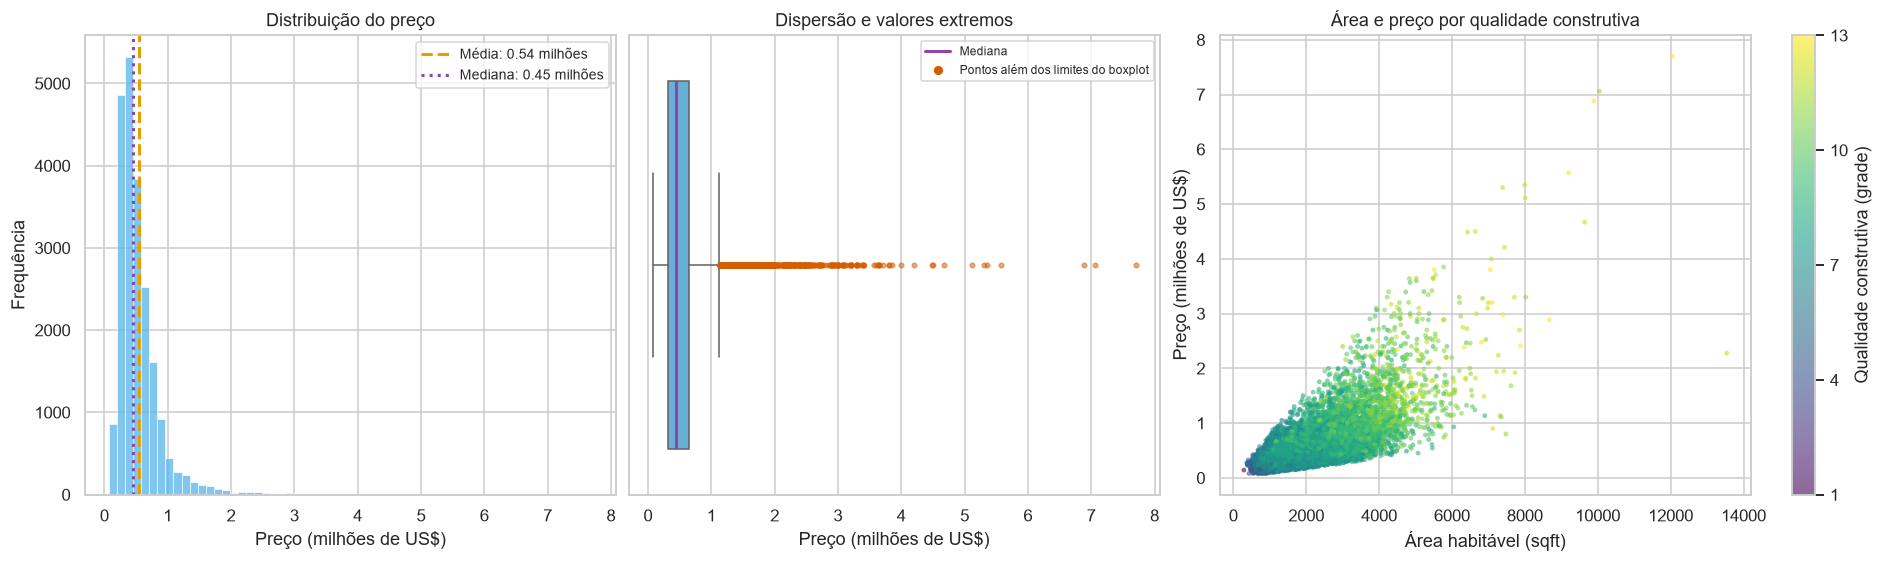

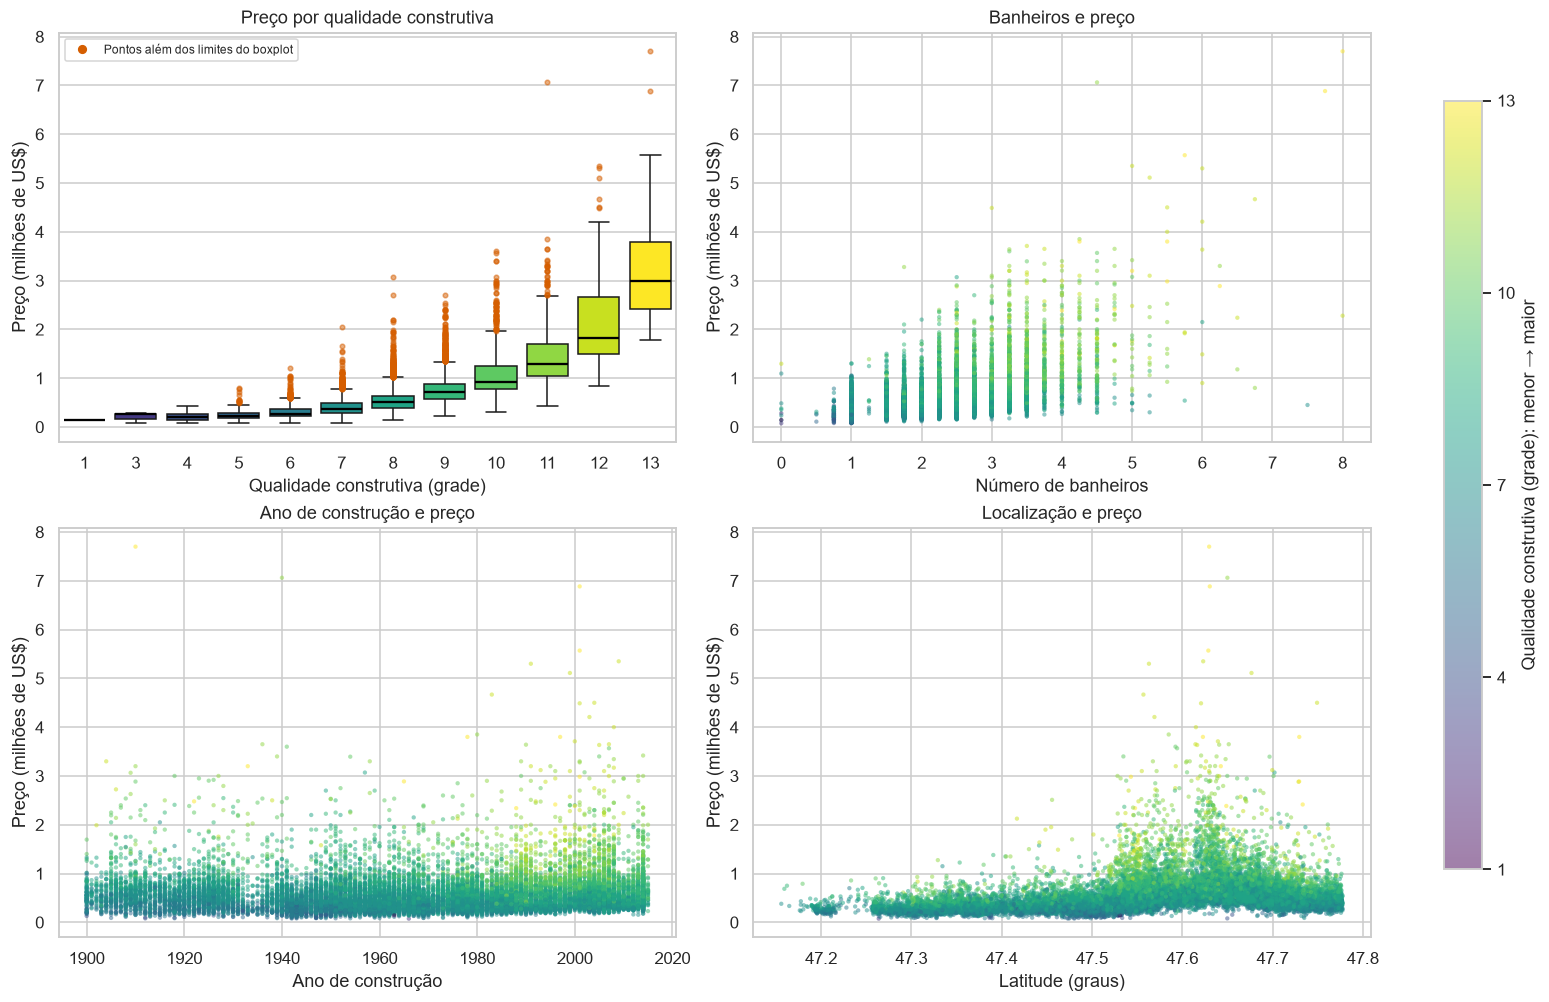

In [9]:
from matplotlib.colors import Normalize
from matplotlib.lines import Line2D

# Cores com significados definidos.
AZUL = '#56B4E9'
LARANJA = '#E69F00'
ROXO = '#8E44AD'
VERMELHO = '#D55E00'

preco_milhoes = dados['price'] / 1e6

# A mesma qualidade construtiva terá a mesma cor em todos os gráficos.
mapa_cores = plt.get_cmap('viridis')
normalizacao = Normalize(vmin=1, vmax=13)

grades = sorted(dados['grade'].unique())
paleta_grade = {
    grade: mapa_cores(normalizacao(grade))
    for grade in grades
}

# Aparência dos pontos além dos limites dos boxplots.
estilo_extremos = {
    'marker': 'o',
    'markerfacecolor': VERMELHO,
    'markeredgecolor': VERMELHO,
    'markersize': 3,
    'alpha': 0.5
}

# ==========================================================
# FIGURA 1 — Distribuição, extremos e relação entre área/preço
# ==========================================================

fig, eixos = plt.subplots(
    1, 3,
    figsize=(17, 5),
    constrained_layout=True
)

# 1. Histograma: destacar média e mediana.
sns.histplot(
    preco_milhoes,
    bins=60,
    ax=eixos[0],
    color=AZUL,
    edgecolor='white'
)

eixos[0].axvline(
    preco_milhoes.mean(),
    color=LARANJA,
    linestyle='--',
    linewidth=2,
    label=f'Média: {preco_milhoes.mean():.2f} milhões'
)

eixos[0].axvline(
    preco_milhoes.median(),
    color=ROXO,
    linestyle=':',
    linewidth=2,
    label=f'Mediana: {preco_milhoes.median():.2f} milhões'
)

eixos[0].set(
    xlabel='Preço (milhões de US$)',
    ylabel='Frequência',
    title='Distribuição do preço'
)
eixos[0].legend(fontsize=9)

# 2. Boxplot: destacar a mediana e os pontos extremos.
sns.boxplot(
    x=preco_milhoes,
    ax=eixos[1],
    color=AZUL,
    medianprops={'color': ROXO, 'linewidth': 2},
    flierprops=estilo_extremos
)

eixos[1].set(
    xlabel='Preço (milhões de US$)',
    title='Dispersão e valores extremos'
)

eixos[1].legend(handles=[
    Line2D(
        [0], [0], color=ROXO, linewidth=2,
        label='Mediana'
    ),
    Line2D(
        [0], [0], marker='o', linestyle='None',
        color=VERMELHO, markersize=5,
        label='Pontos além dos limites do boxplot'
    )
], fontsize=8, loc='upper right')

# 3. Dispersão: a cor representa a qualidade construtiva.
pontos = eixos[2].scatter(
    dados['sqft_living'],
    preco_milhoes,
    c=dados['grade'],
    cmap=mapa_cores,
    norm=normalizacao,
    s=10,
    alpha=0.6,
    edgecolors='none'
)

eixos[2].set(
    xlabel='Área habitável (sqft)',
    ylabel='Preço (milhões de US$)',
    title='Área e preço por qualidade construtiva'
)

fig.colorbar(
    pontos,
    ax=eixos[2],
    label='Qualidade construtiva (grade)',
    ticks=[1, 4, 7, 10, 13]
)

fig.savefig(PASTA / '01_preco_area.png', dpi=150, bbox_inches='tight')
plt.show()

# ==========================================================
# FIGURA 2 — Outras características e preço
# ==========================================================

fig, eixos = plt.subplots(
    2, 2,
    figsize=(14, 9),
    constrained_layout=True
)

# Criar uma coluna auxiliar para usar a mesma unidade em todos os painéis.
dados_grafico = dados.assign(preco_milhoes=preco_milhoes)

# Cada caixa recebe a cor correspondente ao seu grade.
sns.boxplot(
    data=dados_grafico,
    x='grade',
    y='preco_milhoes',
    hue='grade',
    order=grades,
    hue_order=grades,
    palette=paleta_grade,
    dodge=False,
    legend=False,
    saturation=1,
    ax=eixos[0, 0],
    medianprops={'color': 'black', 'linewidth': 1.5},
    flierprops=estilo_extremos
)

eixos[0, 0].set(
    xlabel='Qualidade construtiva (grade)',
    ylabel='Preço (milhões de US$)',
    title='Preço por qualidade construtiva'
)

eixos[0, 0].legend(handles=[
    Line2D(
        [0], [0], marker='o', linestyle='None',
        color=VERMELHO, markersize=5,
        label='Pontos além dos limites do boxplot'
    )
], fontsize=8)

# Nos demais painéis, manter a mesma escala de cores de grade.
colunas = ['bathrooms', 'yr_built', 'lat']
rotulos = [
    'Número de banheiros',
    'Ano de construção',
    'Latitude (graus)'
]
titulos = [
    'Banheiros e preço',
    'Ano de construção e preço',
    'Localização e preço'
]

for ax, coluna, rotulo, titulo in zip(
    eixos.flat[1:], colunas, rotulos, titulos
):
    pontos = ax.scatter(
        dados[coluna],
        preco_milhoes,
        c=dados['grade'],
        cmap=mapa_cores,
        norm=normalizacao,
        s=8,
        alpha=0.5,
        edgecolors='none'
    )

    ax.set(
        xlabel=rotulo,
        ylabel='Preço (milhões de US$)',
        title=titulo
    )

# Barra compartilhada: as cores têm o mesmo significado nos quatro painéis.
fig.colorbar(
    pontos,
    ax=eixos.ravel().tolist(),
    label='Qualidade construtiva (grade): menor → maior',
    ticks=[1, 4, 7, 10, 13],
    shrink=0.85
)

fig.savefig(
    PASTA / '02_demais_variaveis.png',
    dpi=150,
    bbox_inches='tight'
)
plt.show()

**Interpretação dos gráficos:** a concentração de preços menores e a cauda longa à direita mostram assimetria positiva. A relação entre área e preço é positiva, mas existe bastante dispersão: casas com áreas semelhantes podem ter preços diferentes. Isso motiva a inclusão de outras variáveis no MRLM. Os pontos fora dos limites do boxplot são candidatos a inspeção, não erros comprovados.

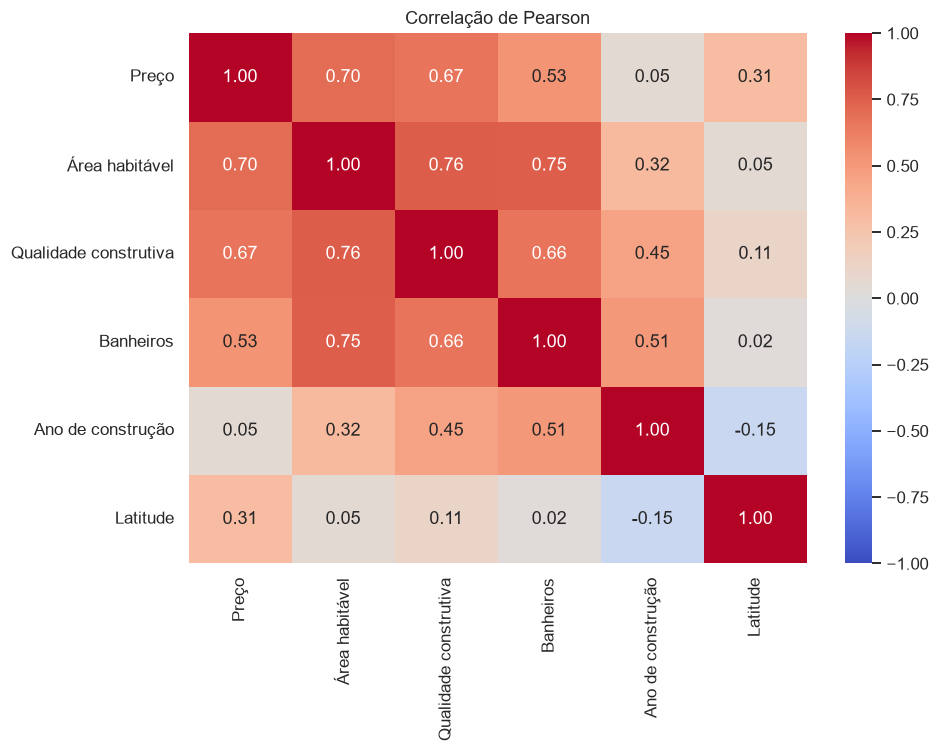

sqft_living    0.70204
grade          0.66743
bathrooms      0.52514
lat              0.307
yr_built      0.054012
Name: correlação_com_preço, dtype: float64

In [10]:
rotulos = {'price':'Preço', 'sqft_living':'Área habitável', 'grade':'Qualidade construtiva',
           'bathrooms':'Banheiros', 'yr_built':'Ano de construção', 'lat':'Latitude'}
correlacoes = dados[variaveis].corr()
plt.figure(figsize=(9,7))
sns.heatmap(correlacoes.rename(index=rotulos,columns=rotulos), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, vmin=-1, vmax=1)
plt.title('Correlação de Pearson')
plt.tight_layout(); plt.savefig(PASTA/'03_correlacoes.png'); plt.show()
display(correlacoes['price'].drop('price').sort_values(ascending=False).rename('correlação_com_preço'))

### 6. Ajuste dos Modelos de Regressão (MRLS e MRLM)
Nesta seção, ajustamos três formulações para investigar as relações propostas:
1. **MRLS:** Preço explicado unicamente pela área habitável (`sqft_living`).
2. **MRLM Linear:** Preço explicado por área habitável, qualidade construtiva (`grade`), banheiros (`bathrooms`), ano de construção (`yr_built`) e localização (`lat`).
3. **MRLM Log-Linear:** Modelo com a resposta em escala logarítmica (`log_price`), fundamentado na assimetria acentuada de 4,024 observada no preço.

In [11]:

dados['log_price'] = np.log(dados['price'])

#  Ajuste do MRLS
mrls = smf.ols('price ~ sqft_living', data=dados).fit()
print("=" * 80)
print("MODELO DE REGRESSÃO LINEAR SIMPLES (MRLS)")
print("=" * 80)
print(mrls.summary())

# Ajuste do MRLM Linear
formula_mrlm = 'price ~ sqft_living + grade + bathrooms + yr_built + lat'
mrlm = smf.ols(formula_mrlm, data=dados).fit()
print("\n" + "=" * 80)
print("MODELO DE REGRESSÃO LINEAR MÚLTIPLA (MRLM)")
print("=" * 80)
print(mrlm.summary())

#  Ajuste do MRLM Transformado (Log-Linear)
formula_log = 'log_price ~ sqft_living + grade + bathrooms + yr_built + lat'
mrlm_log = smf.ols(formula_log, data=dados).fit()
print("\n" + "=" * 80)
print("MODELO DE REGRESSÃO LINEAR MÚLTIPLA TRANSFORMADO (LOG-LINEAR)")
print("=" * 80)
print(mrlm_log.summary())

# Diagnóstico de Multicolinearidade (VIF) nas preditoras
X_vif = dados[preditoras].assign(constante=1)
vif_tabela = pd.DataFrame({
    'Preditora': preditoras,
    'VIF': [variance_inflation_factor(X_vif.values, i) for i in range(len(preditoras))]
}).sort_values(by='VIF', ascending=False)

print("\n" + "=" * 80)
print("FATOR DE INFLAÇÃO DA VARIÂNCIA (VIF)")
print("=" * 80)
display(vif_tabela)
vif_tabela.to_csv(PASTA / 'vif_preditoras.csv', index=False)

MODELO DE REGRESSÃO LINEAR SIMPLES (MRLS)
                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.493
Model:                            OLS   Adj. R-squared:                  0.493
Method:                 Least Squares   F-statistic:                 2.100e+04
Date:                Mon, 05 Oct 2026   Prob (F-statistic):               0.00
Time:                        21:54:53   Log-Likelihood:            -3.0027e+05
No. Observations:               21613   AIC:                         6.005e+05
Df Residuals:                   21611   BIC:                         6.006e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
Intercep

,Preditora,VIF
0,sqft_living,3.4691
2,bathrooms,2.8666
1,grade,2.7998
3,yr_built,1.5522
4,lat,1.0732


### 6.2 Interpretação Estatística do MRLS e Diagnóstico de VIF

#### 1. Modelo de Regressão Linear Simples (MRLS)
* **Poder Explicativo ($R^2 = 0{,}493$):** Apenas a área habitável (`sqft_living`) explica aproximadamente 49,3% de toda a variância observada nos preços dos imóveis. Quase metade da flutuação de preço decorre do tamanho construído da propriedade.
* **Efeito Marginal ($\hat{\beta}_1 = 280{,}62$):** Em média, cada pé quadrado adicional de área habitável está associado a um acréscimo de **US$ 280,62** no preço estimado de venda ($p < 0{,}001$).
* **Intercepto ($\hat{\beta}_0 = -43.580$):** O valor negativo do intercepto reflete apenas o ajuste geométrico da reta na origem ($sqft\_living = 0$), não possuindo significado econômico prático (uma casa com área zero não é comercializada).
* **Diagnóstico Preliminar dos Erros:**
  * O teste de Jarque-Bera ($JB = 546.444{,}71$, $p < 0{,}001$) e a curtose de $26{,}98$ indicam caudas extremamente pesadas e forte desvio da normalidade dos resíduos.
  * A assimetria residual positiva ($2{,}82$) comprova que o modelo linear simples subestima fortemente imóveis de alto padrão e luxo, evidenciando a necessidade de preditoras adicionais e de transformação da escala.

#### 2. Avaliação de Multicolinearidade (VIF)
* Na análise bivariada preliminar, observou-se forte correlação entre área habitável, qualidade construtiva e banheiros ($r > 0{,}65$).
* No entanto, o cálculo do **Fator de Inflação da Variância (VIF)** indicou:
  * `sqft_living`: $3{,}47$
  * `bathrooms`: $2{,}87$
  * `grade`: $2{,}80$
  * `yr_built`: $1{,}55$
  * `lat`: $1{,}07$
* Como todos os fatores permaneceram confortavelmente abaixo do limite crítico comumente aceito na literatura ($VIF < 5$), conclui-se que **não há risco severo de multicolinearidade** inflando os erros-padrão dos coeficientes no MRLM. Todas as preditoras são estruturalmente estáveis para a estimação conjunta.

### 7. Diagnóstico de Observações Atípicas: Outliers, Alavanca e Influência
Nesta etapa, investigamos as observações que se distanciam do padrão amostral e o impacto delas na estabilidade dos coeficientes $\hat{\beta}$:
* **Outliers nos Resíduos:** identificados via Resíduos Estudentizados Internos ($|r_i| > 3$).
* **Pontos de Alavanca ($h_{ii}$):** imóveis com valores atípicos nas variáveis explicativas ($X$). Adota-se o limiar clássico de $2\bar{h} = 2 \times \frac{p}{n}$.
* **Pontos Influentes (Distância de Cook):** mede o deslocamento conjunto nas estimativas $\hat{\beta}$ causado pela exclusão da observação $i$. Adota-se o ponto de corte comumente empregado de $D_i > \frac{4}{n}$.

DIAGNÓSTICO DE OBSERVAÇÕES ATÍPICAS (MRLM)


,Critério,Quantidade,Percentual da Amostra
0,Outliers nos Resíduos (|r_estudentizado| > 3),316,1.46%
1,Alta Alavanca (h_ii > 0.00056),1259,5.83%
2,Altamente Influentes (Cook > 0.00019),1034,4.78%


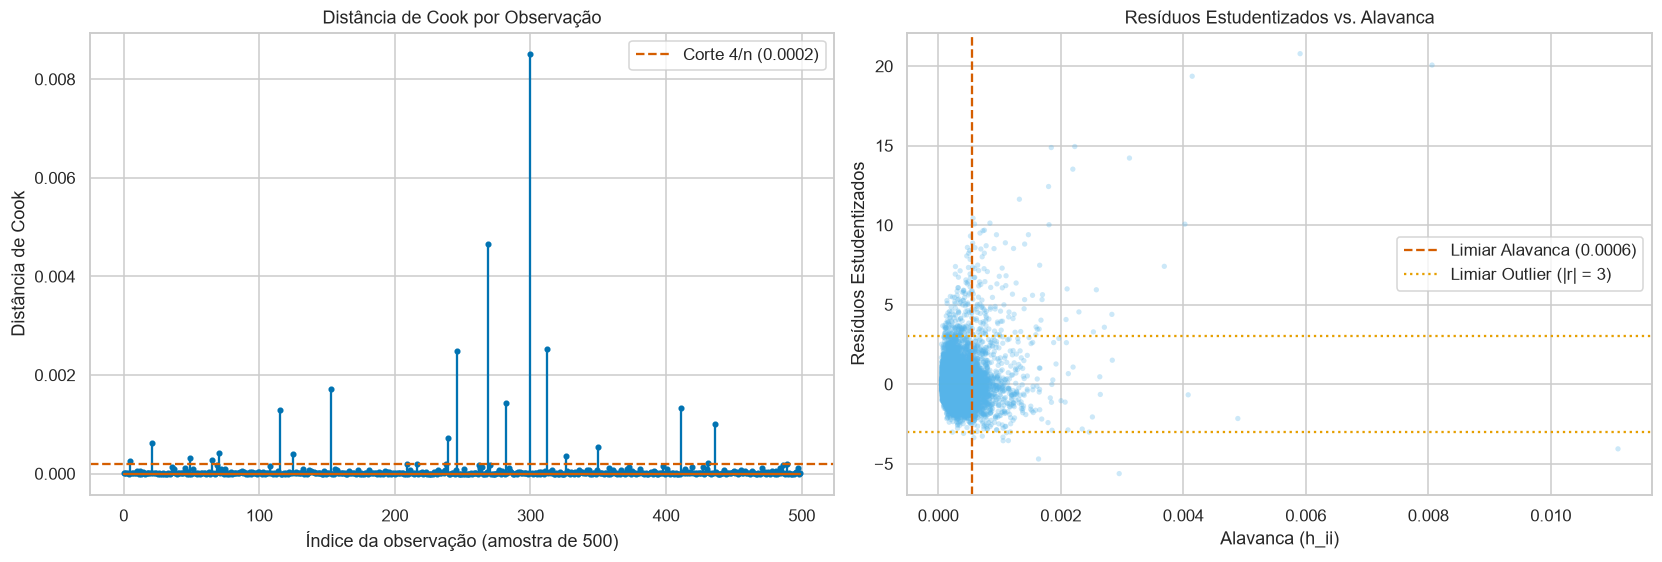

In [12]:
from statsmodels.stats.outliers_influence import OLSInfluence

# Extração das métricas de diagnóstico a partir do MRLM ajustado
influencia = OLSInfluence(mrlm)

# Resíduos estudentizados internos
residuos_student = influencia.resid_studentized_internal

# Medida de Alavanca (diagonal da matriz de projeção Hat)
alavanca = influencia.hat_matrix_diag
n = len(dados)
p = len(mrlm.params)  # intercepto + 5 preditoras = 6
corte_alavanca = 2 * (p / n)

#  Distância de Cook
(distancia_cook, _) = influencia.cooks_distance
corte_cook = 4 / n

# Contagem de casos que ultrapassam os limiares críticos
qtd_outliers = int((np.abs(residuos_student) > 3).sum())
qtd_alavanca = int((alavanca > corte_alavanca).sum())
qtd_influentes = int((distancia_cook > corte_cook).sum())

resumo_atipicos = pd.DataFrame({
    'Critério': [
        'Outliers nos Resíduos (|r_estudentizado| > 3)',
        f'Alta Alavanca (h_ii > {corte_alavanca:.5f})',
        f'Altamente Influentes (Cook > {corte_cook:.5f})'
    ],
    'Quantidade': [qtd_outliers, qtd_alavanca, qtd_influentes],
    'Percentual da Amostra': [
        f'{(qtd_outliers / n) * 100:.2f}%',
        f'{(qtd_alavanca / n) * 100:.2f}%',
        f'{(qtd_influentes / n) * 100:.2f}%'
    ]
})

print("=" * 80)
print("DIAGNÓSTICO DE OBSERVAÇÕES ATÍPICAS (MRLM)")
print("=" * 80)
display(resumo_atipicos)
resumo_atipicos.to_csv(PASTA / 'diagnostico_atipicos.csv', index=False)

# ==========================================================
# FIGURA 5 — Gráficos de Diagnóstico: Alavanca e Distância de Cook
# ==========================================================
fig, eixos = plt.subplots(1, 2, figsize=(15, 5), constrained_layout=True)

# Painel 1: Distância de Cook (primeiros 500 imóveis para visualização nítida)
eixos[0].stem(np.arange(500), distancia_cook[:500], markerfmt='.')
eixos[0].axhline(corte_cook, color=VERMELHO, linestyle='--', label=f'Corte 4/n ({corte_cook:.4f})')
eixos[0].set(
    xlabel='Índice da observação (amostra de 500)',
    ylabel='Distância de Cook',
    title='Distância de Cook por Observação'
)
eixos[0].legend()

# Painel 2: Resíduos Estudentizados vs. Alavanca (Leverage)
eixos[1].scatter(alavanca, residuos_student, alpha=0.3, color=AZUL, s=12, edgecolors='none')
eixos[1].axvline(corte_alavanca, color=VERMELHO, linestyle='--', label=f'Limiar Alavanca ({corte_alavanca:.4f})')
eixos[1].axhline(3, color=LARANJA, linestyle=':')
eixos[1].axhline(-3, color=LARANJA, linestyle=':', label='Limiar Outlier (|r| = 3)')
eixos[1].set(
    xlabel='Alavanca (h_ii)',
    ylabel='Resíduos Estudentizados',
    title='Resíduos Estudentizados vs. Alavanca'
)
eixos[1].legend()

fig.savefig(PASTA / '05_diagnostico_atipicos.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.1 Interpretação do Diagnóstico de Observações Atípicas

1. **Outliers nos Resíduos ($|r_i| > 3$):**
   * Foram identificadas **316 observações (1,46% da amostra)** com resíduos estudentizados além do intervalo $[-3, 3]$[cite: 6].
   * Conforme visível no gráfico de dispersão, há resíduos positivos extremos que chegam a ultrapassar o valor 20[cite: 5]. Isto comprova que o modelo linear subestima substancialmente o valor de mercado de propriedades de altíssimo padrão[cite: 5].

2. **Pontos de Alta Alavanca ($h_{ii} > 0{,}00056$):**
   * Registaram-se **1.259 imóveis (5,83% da amostra)** acima do limiar de corte $2\bar{h} = 2 \times \frac{p}{n}$[cite: 6].
   * Estas observações representam habitações com combinações atípicas no espaço das variáveis explicativas $X$ (por exemplo, áreas habitáveis muito elevadas ou notas de padrão construtivo nos extremos 1 ou 13)[cite: 5].

3. **Pontos Altamente Influentes (Distância de Cook > $0{,}00019$):**
   * Foram sinalizadas **1.034 observações (4,78% da amostra)** com $D_i > \frac{4}{n}$[cite: 6].
   * O gráfico de agulhas (*stem plot*) evidencia picos pronunciados (com valores de $D_i$ a aproximar-se de 0,009), indicando casos que exercem tração desproporcionada na inclinação dos coeficientes $\hat{\beta}$ da reta ajustada[cite: 5].
   * **Conclusão:** A presença destes pontos reforça a sensibilidade do estimador clássico de Mínimos Quadrados Ordinários (MQO) na escala direta em dólares, justificando a avaliação em escala logarítmica ou o recurso a métodos robustos.